# Automatic Music Transcription

In [23]:
# install relevant packages for Google Colab
# !pip install pyguitarpro
# !pip install --upgrade attrs
# !pip install accelerate -U
# !pip install datasets

### Tokenizer

In [1]:
from sklearn.model_selection import train_test_split
import IPython.display as ipd
import copy
import torch
import torch.nn.functional as F
import librosa
import guitarpro
from guitarpro.models import Note, Beat
from transformers import AutoFeatureExtractor, WhisperModel, WhisperConfig, WhisperProcessor
import transformers

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'{device}, {torch.__version__=}, {torch.cuda.is_available()=}, {torch.version.cuda=}, {transformers.__version__=}')

# assert device is cuda or print error that cuda is needed
assert device.type == 'cuda', 'CUDA is not available'

cuda, torch.__version__='2.0.1+cu117', torch.cuda.is_available()=True, torch.version.cuda='11.7', transformers.__version__='4.25.1'


In [45]:
song_filepath = 'dataset/john-mayer/30_Why_Georgia.mp3'
tab_filepath = 'dataset/john-mayer/3_why-georgia.gp5'
vocab_size = 129
wait_token_idx = 127
start_token_idx = 128
end_token_idx = 129

sr = 16000

model_id = "openai/whisper-base"

# Load in the song and tab
y, sr = librosa.load(song_filepath, sr=sr)
song = guitarpro.parse(tab_filepath) 

print(f'{len(y)=}')

len(y)=484922


In [46]:
def tokenize_note_simple(note):
    """
    Tokenizes a note based on its string and fret number.
    """

    string = note.string
    value = note.value

    # Add pre-conditions for the note
    if string < 1 or string > 6:
        raise ValueError(f"Invalid string number: {string}")

    if value < 0 or value > 20:
        raise ValueError(f"Invalid fret number: {value}")

    # Calculate the token index based on string and fret
    # Token range for fretted notes: 1 to 120
    # Token range for open strings: 121 to 126
    if value == 0:  # Open string
        token_index = 121 + (6 - string)
    else:
        token_index = (string - 1) * 20 + value

    return token_index

In [47]:
g_note = Note(Beat(voice=None), string=6, value=3)
g_note_token_idx = tokenize_note_simple(g_note)

print(f'{g_note_token_idx=} for {g_note}')

g_note_token_idx=103 for Note(value=3, velocity=95, string=6, effect=<guitarpro.models.NoteEffect object at 0x7fbac887d190>, durationPercent=1.0, swapAccidentals=False, type=<NoteType.rest: 0>)


In [48]:
def detokenize_note_simple(token_index):
    """
    Detokenizes a token index to find the corresponding guitar string and fret number
    """

    # Pre-conditions for the token index
    if token_index < 1 or token_index > vocab_size:
        raise ValueError(f"Invalid token index: {token_index}")

    # Determining the string and fret based on token index
    if 121 <= token_index <= 126:  # Open string
        string = 6 - (token_index - 121)
        fret = 0
    elif token_index == wait_token_idx:
        return "wait"
    elif token_index == start_token_idx:
        return "start"
    elif token_index == end_token_idx:
        return "end"
    else:
        string = ((token_index - 1) // 20) + 1
        fret = token_index - ((string - 1) * 20)

    return f"s{string}f{fret}"

# Example usage
token_index = 126
note = detokenize_note_simple(token_index)
print(f'{token_index=} maps to {note=}')


token_index=126 maps to note='s1f0'


In [29]:
def tokenize_song_simple(song):
    """
    Tokenizes an entire song using a simplified scheme.
    """
    all_measures_tokens = []

    # Start token for the song
    all_measures_tokens.append([128])  # 128 is the start token

    for track in song.tracks:
        for measure in track.measures:
            measure_tokens = []
            for voice in measure.voices:
                for beat in voice.beats:
                    if track.isPercussionTrack:
                        continue  # Skip percussion tracks
                    else:
                        for note in beat.notes:
                            token = tokenize_note_simple(note)
                            measure_tokens.append(token)

                    # Assuming each beat is a 'wait' token
                    measure_tokens.append(127)  # 127 is the wait/rest token

            # Repeat measures if necessary
            if measure.repeatClose > 0:
                for _ in range(measure.repeatClose):
                    all_measures_tokens.append(measure_tokens)
            else:
                all_measures_tokens.append(measure_tokens)

    # End token for the song
    all_measures_tokens.append([129])  # 129 is the end token

    return all_measures_tokens

In [30]:
# tokenize the acoustic song track only
acoustic_song = copy.deepcopy(song)
acoustic_song.tracks = [acoustic_song.tracks[0]]

tokens = tokenize_song_simple(acoustic_song)

## Audio Segmentation
* Split the audio into segments of roughly the same length as the song measures, which for Why Georgia is roughly 2.5 seconds

In [31]:
# Given parameters
sample_rate = sr
chunk_duration = 2.5  # Chunk duration in seconds, this is the approximate length for each measure
hop_length = 512  # This is the default hop length for librosa's mfcc calculation

# Calculate the number of samples per chunk
samples_per_chunk = int(sample_rate * chunk_duration)

# Calculate the number of chunks
num_chunks = len(y) // samples_per_chunk + 1

# calculate total number of frames
total_frames = len(y) // hop_length + 1

# Calculate the number of frames per chunk
# Formula: Number of Frames = (Number of Samples in Segment - Frame Length) / Hop Length + 1
# Assuming the frame length is equal to the hop length for simplicity
frames_per_chunk = (samples_per_chunk) // hop_length + 1

print(f'{samples_per_chunk=}, {num_chunks=}, {frames_per_chunk=}, {total_frames=}')

samples_per_chunk=40000, num_chunks=13, frames_per_chunk=79, total_frames=948


In [32]:
def extract_audio_segments(y, num_chunks, samples_per_chunk):
    """
    Extracts audio segments from the given waveform y into num_chunks segments.
    """

    # Initialize an empty list to hold the audio segments
    audio_segments = []

    # Iterate over the waveform and extract segments
    for i in range(num_chunks):
        # Calculate the start and end index for each chunk
        start_idx = i * samples_per_chunk
        end_idx = start_idx + samples_per_chunk

        # Make sure the end index does not exceed the length of the waveform
        end_idx = min(end_idx, len(y))

        # Extract the segment and add it to the list
        segment = y[start_idx:end_idx]
        audio_segments.append(segment)

    audio_segments = audio_segments[:-1]  # remove the last segment as it may not be a full measure
    segment_len = len(audio_segments[0])
    
    for segment in audio_segments:
        assert len(segment) == segment_len, "All segments should have the same length"
    
    return audio_segments

audio_segments = extract_audio_segments(y, num_chunks, samples_per_chunk)

### Seq2seq Whisper transformer model

In [33]:
feature_extractor = AutoFeatureExtractor.from_pretrained(model_id)
processor = WhisperProcessor.from_pretrained(model_id)

In [34]:
class CustomWhisperModel(WhisperModel):
    def __init__(self, config: WhisperConfig, vocab_size: int):
        super().__init__(config)
        # Initialize your custom projection layer
        self.proj_out = torch.nn.Linear(256, vocab_size, bias=False)

    def forward(self, input_features, decoder_input_ids=None, attention_mask=None, **kwargs):
        # Invoke the parent forward method
        outputs = super().forward(input_features=input_features, 
                                  decoder_input_ids=decoder_input_ids, 
                                  **kwargs)

        # Apply the projection layer to the final decoder output
        projected_outputs = self.proj_out(outputs.last_hidden_state)

        # Update outputs with the projected outputs
        # Note: You might want to customize this part based on how you wish to use the model's outputs
        outputs.projected_logits = projected_outputs

        return outputs

# Load the original model configuration
config = WhisperConfig()
vocab_size = 129  # Your vocab size
config.vocab_size = vocab_size
config.pad_token_id = wait_token_idx
config.decoder_start_token_id = start_token_idx
config.eos_token_id = end_token_idx
config.bos_token_id = start_token_idx
config.begin_suppress_tokens = None

# Initialize your custom model with the original configuration and your vocab_size
custom_model = CustomWhisperModel(config, vocab_size)

# Move the model to the device
custom_model.to(device)

CustomWhisperModel(
  (encoder): WhisperEncoder(
    (conv1): Conv1d(80, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(256, 256, kernel_size=(3,), stride=(2,), padding=(1,))
    (embed_positions): Embedding(1500, 256)
    (layers): ModuleList(
      (0-5): 6 x WhisperEncoderLayer(
        (self_attn): WhisperAttention(
          (k_proj): Linear(in_features=256, out_features=256, bias=False)
          (v_proj): Linear(in_features=256, out_features=256, bias=True)
          (q_proj): Linear(in_features=256, out_features=256, bias=True)
          (out_proj): Linear(in_features=256, out_features=256, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=256, out_features=1536, bias=True)
        (fc2): Linear(in_features=1536, out_features=256, bias=True)
        (final_layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  

In [35]:
# lets loop through each audio segment and generate the tab
predicted_tokens = []
for i, segment in enumerate(audio_segments):
    input_features = processor(segment, sampling_rate=sr, return_tensors="pt").input_features.to(device)
    custom_model.config.forced_decoder_ids = None
    # pass the input features to the model
    outputs = custom_model(input_features, decoder_input_ids=torch.tensor([start_token_idx]).unsqueeze(0).to(device))
    # predicted_tokens.append(outputs)
    break

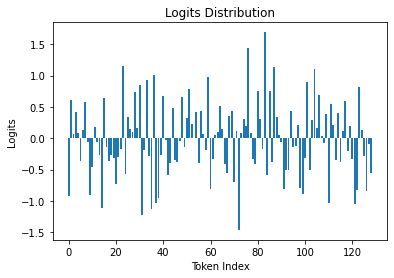

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

projected_logits = outputs.projected_logits
# calculate the probabilities
projected_probs = F.softmax(projected_logits, dim=-1)

projected_logits_cpu = projected_logits.cpu().detach().numpy().squeeze()
plt.bar(range(0, 129), projected_logits_cpu)
plt.xlabel('Token Index')
plt.ylabel('Logits')
plt.title('Logits Distribution')
plt.show()


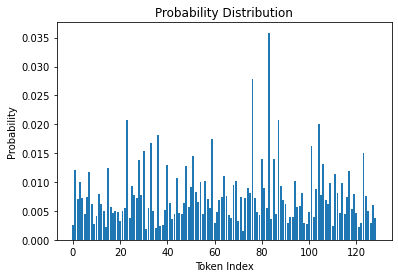

In [37]:
# Plot the probability distribution
probabilities_cpu = projected_probs.cpu().detach().numpy().squeeze()
plt.bar(range(0, 129), probabilities_cpu)
plt.xlabel('Token Index')
plt.ylabel('Probability')
plt.title('Probability Distribution')
plt.show()


In [52]:
# sum all the probabilities
summed_probs = projected_probs.sum(dim=1).cpu().detach().numpy().squeeze()

1.0

In [40]:
# softmax the logits
predicted_tokens = F.softmax(outputs.projected_logits, dim=-1)

In [42]:
# # get the token with the highest probability
highest_pr_token = torch.argmax(predicted_tokens, dim=-1)
print(f'{highest_pr_token.item()=}')

highest_pr_token.item()=83


In [43]:
# Calculate the top-k tokens
top_k = 5
top_k_tokens = torch.topk(predicted_tokens, top_k, dim=-1).indices
print(f'{top_k_tokens=}')

top_k_tokens=tensor([[[ 83,  76,  23,  87, 104]]], device='cuda:0')


In [44]:
len(tokens[2])

31